## 2026_Winter_DL_week5_Homework
CNN 실습 예제코드입니다!

이번 5주차 숙제는 총 2가지로 구성되어 있습니다.
- 논문 리뷰 - ResNet : https://arxiv.org/abs/1512.03385
    - 다음 논문을 읽고 팀별로 논문 스터디 및 정리를 준비해주시면 됩니다! (notion 이나 ppt 로 논문 정리 자료 제작 후에 팀별로 git에 업로드 해주세요 :D)

- 코드 과제 (아래 두 가지 중 택1!)
    - 1) (CNN 을 처음 접해보시거나 기초를 더 다지고 싶은 분들께 추천)
        - 아래 실습코드를 그대로 참고하셔도 좋고, 새롭게 짜셔도 좋습니다. 데이터셋은 CIFAR10이 아닌 벤치마크(MNIST, FFHQ, ImageNet)이나 다른 데이터셋을 사용하되, 학습 시간 및 리소스를 적절히 사용할 수 있는 화질을 사용하는 것을 추천 드립니다. 또한, 앞서 배운 regularization, initialization, optimizer 등등 기법을 추가해보시거나, layer를 변형하는 시도를 추가하여 결과를 분석해주세요.
        - example : Earlystopping 추가, Dropoutlayer 추가, batch nomalization 추가, stride 및 padding 변형, Conv layer 추가 및 삭제 등등
    - 2) (이미 CNN 지식이 있는 분들)
        - ResNet 을 논문 "**만**" 읽고 핵심 모듈 코드를 직접 짜보세요! 코드를 보지 않고 conv block이나 layer들을 논문 기반으로 짜보시면 됩니다.(임교수님께서 추천해주신 공부법입니다 ㅎㅎ)

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.adam import Adam
from torch.utils.data.dataloader import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
from tqdm import tqdm

100%|██████████| 182M/182M [00:03<00:00, 60.4MB/s]
100%|██████████| 64.3M/64.3M [00:01<00:00, 56.5MB/s]


데이터셋 크기: (73257, 3, 32, 32)


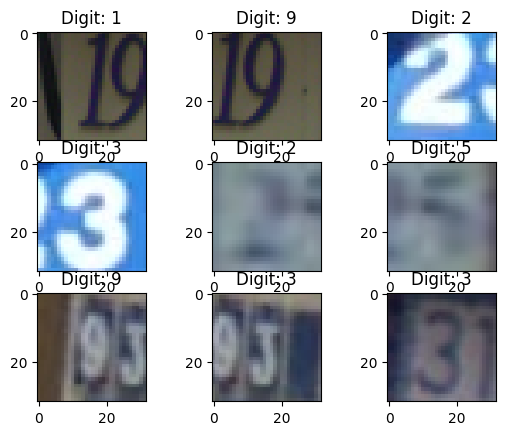

In [4]:
# 데이터셋 정의 -> SVHN (실제 번호판 사진)
train_data = datasets.SVHN(
    './data/',
    split='train',
    download=True,
    transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.RandomCrop(32, padding=2),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ]))

'''
다음과 같이 정의하여 함수형태로 후처리도 가능합니다

transform=transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomCrop(32, padding=2),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_data = data_transform(train_data)
'''

test_data = datasets.SVHN(
    root="../data/",
    split='test',
    download=True,
    transform=transforms.ToTensor())

# 시각화 부분
for i in range(9):
    plt.subplot(3, 3, i+1)
    img = train_data.data[i].transpose(1, 2, 0)
    plt.imshow(img)
    plt.title(f"Digit: {train_data.labels[i]}")

print(f"데이터셋 크기: {train_data.data.shape}")
plt.show()

In [5]:
from torch.utils.data import Dataset

class CustomSVHN(Dataset):
    def __init__(self, root, split='train', download=False):
        # SVHN은 train=True 대신 split='train' 또는 'test'를 사용합니다.
        self.base_dataset = datasets.SVHN(
            root=root,
            split=split,
            download=download
        )

        self.split = split

        # 데이터 증강 및 전처리 설정
        self.transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.RandomCrop(32, padding=2),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])

    def __len__(self):
        return len(self.base_dataset.data)

    def __getitem__(self, idx):
        # SVHN의 데이터 구조는 (C, H, W)이므로 변환이 필요함.
        image = self.base_dataset.data[idx].transpose(1, 2, 0) # (H, W, C)로 변경
        label = self.base_dataset.labels[idx]

        if self.split == 'train':
            image = self.transform(image)
        else:
            eval_transform = transforms.Compose([
                transforms.ToPILImage(),
                transforms.ToTensor(),
                transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
            ])
            image = eval_transform(image)

        return image, label

# 인스턴스 생성
train_data = CustomSVHN(root='./data/', split='train', download=True)
test_data = CustomSVHN(root='./data/', split='test', download=True)

100%|██████████| 64.3M/64.3M [00:01<00:00, 44.5MB/s]


## Modeling

In [6]:
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, hidden_dim, stride=1):
        super(BasicBlock, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, hidden_dim, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(hidden_dim) # Batch Normalization 추가

        self.conv2 = nn.Conv2d(hidden_dim, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels) # Batch Normalization 추가

        self.relu = nn.ReLU()

        # 2. Skip Connection (Identity Shortcut) 추가
        # 입력과 출력의 채널이 다를 때만 1x1 conv로 차원을 맞춤
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = self.shortcut(x) #

        out = self.conv1(x)
        out = self.bn1(out) # 활성화 함수 전 BN 적용
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out += identity # Residual Addition
        out = self.relu(out)
        return out

In [7]:
class CNN(nn.Module):
    def __init__(self, num_classes=10):
        super(CNN, self).__init__()

        self.block1 = BasicBlock(in_channels=3, out_channels=32, hidden_dim=32, stride=1)
        self.block2 = BasicBlock(in_channels=32, out_channels=64, hidden_dim=64, stride=2)  # 여기서 크기 16x16으로 감소
        self.block3 = BasicBlock(in_channels=64, out_channels=128, hidden_dim=128, stride=2) # 여기서 크기 8x8로 감소
        self.block4 = BasicBlock(in_channels=128, out_channels=256, hidden_dim=256, stride=2) # 여기서 크기 4x4로 감소

        self.dropout = nn.Dropout(0.5) # Regularization: Dropout 추가

        self.fc1 = nn.Linear(in_features=4096, out_features=1024)
        self.fc2 = nn.Linear(in_features=1024, out_features=256)
        self.fc3 = nn.Linear(in_features=256, out_features=num_classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)

        x = torch.flatten(x, start_dim=1)

        x = self.relu(self.fc1(x))
        x = self.dropout(x) # 과적합 방지
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [8]:
from torch.utils.data.dataloader import DataLoader

from torch.optim.adam import Adam


# 데이터로더 정의
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

# 학습을 진행할 프로세서 설정
device = "cuda" if torch.cuda.is_available() else "cpu"


print(f"device 정보: {device}")

# CNN 모델 정의
model = CNN(num_classes=10)

# 모델을 device로 보냄
model.to(device)

device 정보: cuda


CNN(
  (block1): BasicBlock(
    (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU()
    (shortcut): Sequential(
      (0): Conv2d(3, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (block2): BasicBlock(
    (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)


In [9]:
# Loss 함수 선언
criterion = nn.CrossEntropyLoss()

# Optimizer and Scheduler (L2 규제 및 학습률 자동 조절 추가)
optimizer = Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3)

best_acc = 0
patience_counter = 0
early_stop_patience = 7

for epoch in range(100):
    # Train 단계
    model.train() # 학습 모드
    train_loss = 0
    for data, label in tqdm(train_loader, desc=f"Epoch {epoch+1} Train"):
        data, label = data.to(device), label.to(device)

        optimizer.zero_grad()
        preds = model(data)
        loss = criterion(preds, label)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # Evaluation 단계
    model.eval() # 평가 모드
    val_loss = 0
    num_corr = 0

    with torch.no_grad(): # 기울기 계산 비활성화로 메모리 절약
        for data, label in tqdm(test_loader, desc=f"Epoch {epoch+1} Test"):
            data, label = data.to(device), label.to(device)

            outputs = model(data)
            v_loss = criterion(outputs, label)
            val_loss += v_loss.item()

            # 정확도 계산 로직
            preds = outputs.data.max(1)[1]
            num_corr += preds.eq(label.data).sum().item()

    # Test loss 및 Test Accurarcy 정의
    avg_val_loss = val_loss / len(test_loader)
    accuracy = 100 * num_corr / len(test_data)

    # 결과 출력
    print(f"\nEpoch {epoch+1}: Train Loss: {train_loss/len(train_loader):.4f} | "
          f"Test Loss: {avg_val_loss:.4f} | Test Acc: {accuracy:.2f}%")

    # Early Stopping and Scheduler Logic
    scheduler.step(avg_val_loss) # 검증 손실에 따라 학습률 조정

    if accuracy > best_acc:
        best_acc = accuracy
        torch.save(model.state_dict(), "best_SVHN.pth") # 최고 성능 모델 저장
        patience_counter = 0
        print(f"--- Best Model Saved! (Acc: {best_acc:.2f}%) ---")
    else:
        patience_counter += 1

    if patience_counter >= early_stop_patience:
        print(f"Early Stopping at epoch {epoch+1}!")
        break

Epoch 1 Test: 100%|██████████| 407/407 [00:09<00:00, 41.73it/s]



Epoch 1: Train Loss: 0.8230 | Test Loss: 0.3492 | Test Acc: 89.66%
--- Best Model Saved! (Acc: 89.66%) ---


Epoch 2 Test: 100%|██████████| 407/407 [00:09<00:00, 42.75it/s]



Epoch 2: Train Loss: 0.3794 | Test Loss: 0.2647 | Test Acc: 92.59%
--- Best Model Saved! (Acc: 92.59%) ---


Epoch 3 Test: 100%|██████████| 407/407 [00:12<00:00, 33.19it/s]


...


Epoch 20: Train Loss: 0.0699 | Test Loss: 0.1544 | Test Acc: 96.08%


Epoch 21 Test: 100%|██████████| 407/407 [00:09<00:00, 42.71it/s]



Epoch 21: Train Loss: 0.0686 | Test Loss: 0.1581 | Test Acc: 96.07%


Epoch 22 Test: 100%|██████████| 407/407 [00:09<00:00, 44.02it/s]


Epoch 22: Train Loss: 0.0672 | Test Loss: 0.1570 | Test Acc: 96.07%
Early Stopping at epoch 22!



*   SVHN 데이터를 활용하여, 본 모델은 Epoch 22에서 Test Accuracy 96.07%를 기록하며 안정적으로 수렴하였습니다.
*   과적합 방지를 위한 조기 종료(Early Stopping) 메커니즘을 통해 모델의 신뢰성을 확보하였습니다.

*   Residual Learning 개념을 도입하여 효율적인 학습을 수행했습니다.

*   Batch Normalization이 초기 학습 속도를 비약적으로 높였음을 증명합니다.

*  각 에포크당 학습(Train)은 약 43초, 테스트(Test)는 약 9초 내외로 수행되었습니다. 이는 batch_size=64 설정과 GPU 가속이 적절히 조화되어 연산 자원을 최적으로 활용하고 있음을 보여줍니다.
